# Ontario Education & OSAP

This notebook aims to quantify returns to post-secondary education (covered under OSAP), analyse OSAP's latest policies, and see if the one matches the other - if getting tertiary education is worth it given OSAP financing arrangements, especially loan burdens.

For this notebook, I will be using [StatCan's Census 2021 PUMF Individual data](https://www150.statcan.gc.ca/n1/pub/98m0001x/index-eng.htm). Since we don't want to analyse structures (i.e. families), we don't need hierarchical data.

To quantify and analyse the returns to post-secondary education, we need a few things. First, we need a metric to compare against - the median income of someone who won't get post-secondary education. A counterfactual would be ideal - the sort of person who gets post-secondary education is not guaranteed to earn the same in, say, the trades as a tradesman. They may earn more, or they may earn less. Instead of comparing Person A who gets post-secondary education to Person B who doesn't, a detailed analysis would compare Person A who gets post-secondary education to Person A who doesn't. But constructing such a model seems complex, so we will simply compare median earnings.

Once we've constructed that model, we need to quantify the returns to post-secondary education. Median wages vary by degree, field, and experience, even gender, so we will need to control or analyse these variables separately.

Finally, we'll need to do some accounting calculations: given OSAP's financing burden, does an investment in education (given the above models) make sense? In technical terms, I'm going to calculate the NPV (value of investment) of the earnings premium (of education) net (minus) of loan repayment costs, and maybe compared across grant/loan ratios.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns

## Pre-processing

Census 2021's PUMF data is massive. I will filter the file prior to working with it to minimise space-used. It is also complex, primarily using codes for characteristics and values. I will handle this all early.

The characteristics I'm filtering for:
1. PPSORT - Unique ID
2. AGEGRP - AGE
3. CIP2021 - Fields of Study
4. EmpIn - Income: Employment income
5. Gender - Gender
6. HDGREE - Education: Highest certificate, diploma or degree
7. LFACT - Labour: Labour force status - Detailed
8. PR - Province

In [5]:
# Filter for variables and load csv
cols = ['PPSORT', 'AGEGRP', 'CIP2021', 'EmpIn', 'Gender', 'SSGRAD', 'LFACT', 'PR']
census_2021 = pd.read_csv('census_2021_ontario.csv', usecols=cols)
# Filter for Ontario only
census_2021 = census_2021[census_2021['PR'] == 35]
# Remove NA
census_2021 = census_2021[census_2021['EmpIn'] != 99999999]
census_2021 = census_2021[census_2021['EmpIn'] != 88888888]
census_2021 = census_2021[~census_2021['SSGRAD'].isin([88, 99])]
census_2021 = census_2021[~census_2021['AGEGRP'].isin([88])]
census_2021 = census_2021[~census_2021['CIP2021'].isin([88, 99])]
census_2021 = census_2021[~census_2021['LFACT'].isin([88, 99])]
# Filtering for working age
census_2021 = census_2021[census_2021['AGEGRP'].isin(range(8,17))]
# Filter for positive income
census_2021 = census_2021[census_2021['EmpIn'] >= 0]

census_2021.head()

,PPSORT,AGEGRP,CIP2021,EmpIn,Gender,LFACT,PR,SSGRAD
0,2,11,8,12000,1,3,35,6
1,8,16,4,61000,1,13,35,11
3,10,12,13,25000,2,1,35,4
4,12,13,5,130000,1,1,35,8
8,21,10,5,63000,1,1,35,11


In [6]:
SSGRAD = {
    1:  'No certificate',
    2:  'Trades (no HS)',
    3:  'College/CEGEP (no HS)',
    4:  'HS',
    5:  'Trades',
    6:  'College/CEGEP',
    7:  'University below bachelor',
    8:  'Bachelor',
    9:  'University above bachelor',
    10: 'Medicine/Dentistry/Vet/Optometry',
    11: 'Masters',
    12: 'Doctorate',
    88: None,  # Not available
    99: None   # Not applicable
}


GENDER = {
    1: "Woman",
    2: "Man"
}

AGEGRP = {
    4: "10-11",
    19: "75-79",
    16: "60-64",
    10: "30-34",
    11: "35-39",
    2: "5-6",
    17: "65-69",
    3: "7-9",
    1: "0-4",
    20: "80-84",
    12: "40-44",
    8: "20-24",
    6: "15-17",
    7: "18-19",
    18: "70-74",
    13: "45-49",
    88: None,
    14: "50-54",
    9: "25-29",
    21: "85+",
    5: "12-14",
    15: "55-59",
}

CIP2021 = {
    11: "Personal/protective/transport services",
    8: "Architecture/engineering/trades",
    99: None,
    3: "Humanities",
    10: "Health",
    7: "Math/CS/info",
    88: None,
    4: "Social sciences & law",
    9: "Agriculture/natural resources/conservation",
    5: "Business/management/public admin",
    1: "Education",
    13: "No postsecondary degree",
    12: "Other",
    2: "Visual/performing arts & comm",
    6: "Physical/life sciences & tech",
}

LFACT = {
    1:  'Employed',
    2:  'Employed - Absent',
    3:  'Unemployed',
    4:  'Unemployed',
    5:  'Unemployed',
    6:  'Unemployed',
    7:  'Unemployed',
    8:  'Unemployed',
    9:  'Unemployed',
    10: 'Unemployed',
    11: 'Not in labour force',
    12: 'Not in labour force',
    13: 'Not in labour force',
    14: 'Not in labour force',
    88: None,
    99: None
}

## Constructing the Alternate

First, we will find the median income of the average non-post secondary educated person. This includes those with a high school education, tradesmen, career college diplomas, and so on.

In [7]:
non_ps_df = census_2021[census_2021['SSGRAD'].isin([1, 2, 4, 5])]
non_ps_df['EmpIn'].median()

np.float64(33000.0)

The median non-post secondary educated person in Ontario earns $33,000 per year. This figure accounts for the unemployed, and not for those with negative income.

In [8]:
non_ps_df[non_ps_df['LFACT'].isin([1, 2])]['EmpIn'].median()

np.float64(42000.0)

Filtering for the employed only, that number increases to $42000 per year.

## Returns to Education

The Mincer earnings function, given wages (their log, to be specific), years of experience, and years of education (alongside other independent variables), models an individuals earnings as a function of these variables, allowing us to calculate the value of, for instance, an additional year of schooling. It's identical to what I did in the last post, with two distinctions - first, we're tracking multiple independent variables (schooling, exp, gender); second, we're using the log of wages. This is because we want the percentage increase of our coefficients, not their absolute increase.

There are some limitations, specific to my data and general to the model. I only have age groups, so I will have to use midpoints - this affects years of experience. Furthermore, my formula for years of experience is simply: age - (years of schooling + 6). This does not account for unemployment and other such things.

Years of education are guessed for some groups with non-post-secondary education - it is impossible to get an exact year for, say, someone who has neither an HS diploma or degree.

### Code

In [9]:
mincer_df = census_2021.copy()

# Map degree to years of schooling
edu_years = {
    1:  10,  # No certificate — assume some high school
    2:  11,  # Trades no HS — HS dropout + trades
    3:  13,  # College no HS — assume completed college
    4:  12,  # HS diploma only
    5:  13,  # Trades + HS — 12 + ~1 year trades
    6:  14,  # College/CEGEP — 12 + 2
    7:  14,  # University below bachelor — 12 + 2
    8:  16,  # Bachelor — 12 + 4
    9:  17,  # University above bachelor — 12 + 5
    10: 18,  # Medicine/Dentistry/Vet — 12 + 4 + 2 specialty minimum
    11: 18,  # Masters — 12 + 4 + 2
    12: 21,  # Doctorate — 12 + 4 + 5
}
age_midpoint = {
    8:  22,   # 20-24
    9:  27,   # 25-29
    10: 32,   # 30-34
    11: 37,   # 35-39
    12: 42,   # 40-44
    13: 47,   # 45-49
    14: 52,   # 50-54
    15: 57,   # 55-59
    16: 62,   # 60-64
}

mincer_df['log_wage'] = np.log(mincer_df['EmpIn'])
mincer_df['age_mid'] = mincer_df['AGEGRP'].map(age_midpoint)
mincer_df['edu_years'] = mincer_df['SSGRAD'].map(edu_years)
mincer_df['exp_years'] = mincer_df['age_mid'] - (mincer_df['edu_years'] + 6)
mincer_df['exp_years'] = mincer_df['exp_years'].clip(lower=0)

mincer_df

,PPSORT,AGEGRP,CIP2021,EmpIn,Gender,LFACT,PR,SSGRAD,log_wage,age_mid,edu_years,exp_years
0,2,11,8,12000,1,3,35,6,9.392662,37,14,17
1,8,16,4,61000,1,13,35,11,11.018629,62,18,38
3,10,12,13,25000,2,1,35,4,10.126631,42,12,24
4,12,13,5,130000,1,1,35,8,11.775290,47,16,25
8,21,10,5,63000,1,1,35,11,11.050890,32,18,8
...,...,...,...,...,...,...,...,...,...,...,...,...
378842,980851,11,8,180000,1,1,35,12,12.100712,37,21,10
378843,980852,12,13,49000,2,1,35,1,10.799576,42,10,26
378844,980856,12,10,110000,1,1,35,6,11.608236,42,14,22
378846,980862,16,13,33000,1,1,35,4,10.404263,62,12,44


In [10]:
model = sm.OLS.from_formula('log_wage ~ edu_years + exp_years + I(exp_years**2) + C(Gender)', data=mincer_df)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_wage   R-squared:                       0.102
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     5217.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:07:21   Log-Likelihood:            -3.3964e+05
No. Observations:              182864   AIC:                         6.793e+05
Df Residuals:                  182859   BIC:                         6.793e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.0040      0.027    264.176      0.000       6.952       7.056
C(Gender)[T.2]        0.3884      0.007     53.291      0.000       0.374       0.403
edu_years             0.1497      0.002     90.663      0.000       0.146       0.153
exp_years             0.1044      0.001     94.200      0.000       0.102       0.107
I(exp_years ** 2)    -0.0020   2.43e-05    -80.547      0.000      -0.002      -0.002
==============================================================================
Omnibus:                   142020.638   Durbin-Watson:                   1.997
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3451730.600
Skew:                          -3.609   Prob(JB):                         0.00
Kurtosis:                      23.023   Cond. No.                     6.39e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.39e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Since we are using `ln(wage)` (we have a log-level model), we need to adjust the coefficients to get proper slopes.

In [11]:
params = results.params
adjusted_params = (np.exp(params) - 1) * 100
adjusted_params

Intercept            110006.516586
C(Gender)[T.2]           47.455093
edu_years                16.143483
exp_years                10.999062
I(exp_years ** 2)        -0.195553
dtype: float64

### Interpretation

We have three independent variables we're tracking: years of schooling, experience, and gender. Our `R-squared` is equal to `0.102`, which means that 10% of the variation in employment income is explained by these factors.  All these variables are statistically significant (`P>|t| < 0.05`).

Our baseline is a male with 0 years of education and experience. An additional year of schooling (for such a person) gives us a `16.1%` increase in wages. An additional year of experience gives us `11%` more wages, but with a diminishing return of `0.2pp` each year.

Our data also shows that men earn `47.46%` more than women.

Importantly, we can now model incomes based on a hypothetical person's education, experience, and gender.

In [12]:
baseline = results.predict({'edu_years': 12, 'exp_years': 2, 'Gender': 2})
# HS degree, 2 years of experience, male
np.exp(baseline[0])

np.float64(11957.7402224044)

## The Costs of Education

The purpose of this article is to see how OSAP policy changes affect an individual's choice of education. Starting from the year 2026-27, OSAP has tweaked its grant:loans ratio to 25:75, at a maximum. The exact ratio may be 0:100, depending on an individual's financial background. We will be testing variations up to the maximum.

One question is how *much* money our model should expect from OSAP. Again, this depends on an individual's background. Some individuals can expect a near 100% cover, while others will receive nothing. Moreover, the ratio and level of financing are tightly linked: an individual who receives a 100% cover will likely also get the maximum 25:75 ratio because both factors are determined by financial background.

Generally, the costs of post-secondary education are many. Our model covers experience - every year spent in post-secondary is one less year of experience compared to the person who skipped it. Some costs are deceptive - we could include rent and other living expenses, but these are independent of post-secondary education.

## Simple NPV of Education

To cut through the fog, we will start with a simple calculation. We will ignore OSAP and other factors, and simply see if, ceteris paribus, education is a worthwhile investment using the Net Present Value formula. The NPV formula is expressed as such:

`NPV = sum(net_cash_flow / (1 + discount_rate)^time) - costs`

Our costs will be the costs of education (tuition, fees) and the foregone wages (opportunity cost). [Ontariocolleges.ca](https://www.ontariocolleges.ca/en/fees-and-aid/tuition) provides a number: 6100 (tuition) + 800 (fees) + 1300 (books and supplies for a total $8200 per academic year. I will assume a bachelors degree. Note that this is an average, exact costs will depend on institution. It also assumes Ontario, despite OSAP covering out-of-province study in certain cases. Our discount rate will be the rate of interest. Our net cash flow will be earnings post-degree. Time will be a working lifetime. Gender will be male (for our example).

This can be quite confusing. It serves to express this in tabular form once to get the general gist of how it works. First, we need to get our cash flows down.

In [13]:
post_sec = []
post_sec[0:3] = [-8200] * 4 # adding college costs
# getting the rest of the cash flow of our post-sec model
for exp in range(22,66):
    post_sec.append(np.exp(results.predict({'edu_years': 16, 'exp_years': exp-22, 'Gender': 2})[0]))
hs = [] # same but for our hs model
for exp in range(18,66):
    hs.append(np.exp(results.predict({'edu_years': 12, 'exp_years': exp-18, 'Gender': 2})[0]))
data = [post_sec, hs]
cash_flow = pd.DataFrame(data=list(zip(*data)), columns=['post_sec', 'hs'], index=range(0, 48))
cash_flow

,post_sec,hs
0,-8200.000000,9781.623220
1,-8200.000000,10836.277815
2,-8200.000000,11957.740222
3,-8200.000000,13143.707352
4,17798.782943,14390.849470
5,19717.847682,15694.763037
6,21758.476883,17049.940925
7,23916.479808,18449.762380
8,26185.797625,19886.504769
9,28558.417591,21351.378687


In [14]:
# crunching the numbers
cash_flow['net_ps'] = cash_flow['post_sec'] / (1 + 0.03) ** cash_flow.index
cash_flow['net_hs']= cash_flow['hs'] / (1 + 0.03) ** cash_flow.index
male_npv = cash_flow['net_ps'].sum() - cash_flow['net_hs'].sum()
male_npv

np.float64(356221.5858905276)

The data seems to tell us that college education is a great investment. A NPV of $356,222, specifically.

There's a few complications here, though. Of course, financing the initial investment is difficult, which is why we have to bring OSAP into our calculations. This doesn't present the whole story.

The main specific issue is unemployment - my numbers account for unemployment, so the unemployed are dragging the wages down (hence the somewhat odd, below minimum wage, numbers for initial years). Since we're doing this for both HS and PS models, it cancels out somewhat. Employment chances are pretty important for decisions such as these, so accounting for unemployment seems sensible, but it does make our figures somewhat less precise.

Moreover, we're assuming a Bachelor's degree, and not accounting for field of study. For our non-post-sec model, we're only assuming a high-school degree when trades are also an option. These variables will be covered later on.

For clarity's sake, I'll recrunch the numbers for a female model too.

In [15]:
post_sec_fem = []
post_sec_fem[0:3] = [-8200] * 4
for exp in range(22,66):
    post_sec_fem.append(np.exp(results.predict({'edu_years': 16, 'exp_years': exp-22, 'Gender': 1})[0]))
hs_fem = []
for exp in range(18,66):
    hs_fem.append(np.exp(results.predict({'edu_years': 12, 'exp_years': exp-18, 'Gender': 1})[0]))
data = [post_sec_fem, hs_fem]
cash_flow_fem = pd.DataFrame(data=list(zip(*data)), columns=['post_sec', 'hs'], index=range(0, 48))
cash_flow_fem

,post_sec,hs
0,-8200.000000,6633.628607
1,-8200.000000,7348.866430
2,-8200.000000,8109.411478
3,-8200.000000,8913.701861
4,12070.646461,9759.479442
5,13372.103537,10643.757863
6,14756.002297,11562.802341
7,16219.500697,12512.122862
8,17758.489805,13486.482148
9,19367.535597,14479.919465


In [16]:
# crunching the numbers
cash_flow_fem['net_ps'] = cash_flow_fem['post_sec'] / (1 + 0.03) ** cash_flow_fem.index
cash_flow_fem['net_hs']= cash_flow_fem['hs'] / (1 + 0.03) ** cash_flow_fem.index
fem_npv = cash_flow_fem['net_ps'].sum() - cash_flow_fem['net_hs'].sum()
fem_npv

np.float64(231476.0626947455)

For women, the NPV is $231,476. This is an interesting result - common-sense tells us that women benefit more from college than men because the sort of jobs that don't require college degrees are less-suited for them (for whatever reason). This value seems to contradict that.

However, this is an absolute number. It makes sense for the absolute number to be lower, because of the gender pay gap we quantified earlier in this notebook. Once we account for that, by modeling the relative ROI, what do the results look like?

In [17]:
hs_male_pv = cash_flow['net_hs'].sum()
hs_fem_pv = cash_flow_fem['net_hs'].sum()

male_roi = (male_npv / hs_male_pv) * 100
fem_roi = (fem_npv / hs_fem_pv) * 100

print(f"Male ROI: {male_roi:.1f}%")
print(f"Female ROI: {fem_roi:.1f}%")

Male ROI: 52.2%
Female ROI: 50.0%


The results seem to be similar. This does not contradict the intuition, however. Our model fails to capture some considerations. For starters, our coefficient for edu_years already accounts for both female *and* male returns together. We'd have to calculate two seperate slopes, and *then* our result would be cleaner. The exact idea behind women and edcation is quite complex, and goes beyond just a simple wage model's capabilities too. That's for another day, though.

## Accounting for OSAP

Regardless, now that we have a base model, and have determined that education makes sense *if* you can afford initial costs, we can move onto accounting for OSAP. We will assume a 100% OSAP coverage, with variations in grants:loans ratio. Why? Well, if you have 0% OSAP coverage you can either not afford college or will pay using a RESP or some other means: for the former, this model is useless in any case, and in the latter case the answer is yes - our 'naive' model says you should go to college.

The case of varying proportions of OSAP and misc coverage is more complex (i.e. 50% OSAP, 50% other sources). However, there is no need to cover that. This is because, if 100% OSAP (meaning a large loan burden) is still a positive investment, then a lower proportion of OSAP funds should generally be the same as well.

OSAP, including loans, does cover non-tuition/fees/books expenses. I made the decision not to include these since these exist for HS too, and I won't include them in this model either.

OSAP loans need to be repayed 6 months after graduating (for simplicities' sake, I'll put that as starting in the fifth year). The time horizon is 9.5 years. 70% of the debt is 0-interest federal, while 30% is provincial and has an interest rate of: `prime-rate + 1%`. The current prime-rate is 4.45%, but this varies. OSAP has a [handy calculator](https://osap.gov.on.ca/AidEstimator2526Web/enterapp/debt_calculator.xhtml) that contains more details.

Once we are done with that, we will finally control for fields of study and exact degree variation. 

In [18]:
def osap_loan(grant_ratio=0.25, total_osap=8200*4, interest_rate=0.06):
    """Given grant_ratio, loan, and interest rate, calculates and returns annuity"""
    loan = total_osap * (1 - grant_ratio)
    loan_fed = loan * 0.75
    loan_prov = loan * 0.25

    annual_payment = loan_prov * (interest_rate * (1 + interest_rate)**10) / ((1 + interest_rate)**10 - 1)
    annual_payment += loan_fed / 10

    return annual_payment

osap_loan()

2680.58794305536

In [19]:
def osap_npv(ratio, main_edu=16, sec_edu=12, main_model=results, sec_model=results, bFos=False, fos=None):
    """Given a OLS model, education for main and counterfactual model, grant ratio, returns NPV for each gender"""
    main_male = [0 for x in range(18,66)]
    sec_male = [0 for x in range(18,66)]
    main_female = [0 for x in range(18,66)]
    sec_female = [0 for x in range(18,66)]
    sec_range = sec_edu - 12

    for exp in range(22,66):
        if bFos:
            main_male[exp - 18] = np.exp(main_model.predict({'edu_years': main_edu, 'exp_years': exp-22, 'Gender': 2, 'FOS': fos})[0])
            main_female[exp - 18] = np.exp(main_model.predict({'edu_years': main_edu, 'exp_years': exp-22, 'Gender': 1, 'FOS': fos})[0])
        else:
            main_male[exp - 18] = np.exp(main_model.predict({'edu_years': main_edu, 'exp_years': exp-22, 'Gender': 2})[0])
            main_female[exp - 18] = np.exp(main_model.predict({'edu_years': main_edu, 'exp_years': exp-22, 'Gender': 1})[0])

    for exp in range(18 + sec_range,66):
        if bFos:
            sec_male[exp - 18] = np.exp(sec_model.predict({'edu_years': sec_edu, 'exp_years': exp-(18 + sec_range), 'Gender': 2, 'FOS': fos})[0])
            sec_female[exp - 18] = np.exp(sec_model.predict({'edu_years': sec_edu, 'exp_years': exp-(18 + sec_range), 'Gender': 1, 'FOS': fos})[0])
        else:
            sec_male[exp - 18] = np.exp(sec_model.predict({'edu_years': sec_edu, 'exp_years': exp-(18 + sec_range), 'Gender': 2})[0])
            sec_female[exp - 18] = np.exp(sec_model.predict({'edu_years': sec_edu, 'exp_years': exp-(18 + sec_range), 'Gender': 1})[0])

    annual_payment = osap_loan(grant_ratio=ratio/100)
        
    main_male[4:14] = [x - annual_payment for x in main_male[4:14]]
    main_female[4:14] = [x - annual_payment for x in main_female[4:14]]

    data = [main_male, sec_male, main_female, sec_female]
    cash_flow_osap = pd.DataFrame(data=list(zip(*data)), columns=['main_male', 'sec_male', 'main_female', 'sec_female'], index=range(0, 48))
    cash_flow_osap['net_main_male'] = cash_flow_osap['main_male'] / (1 + 0.03) ** cash_flow_osap.index
    cash_flow_osap['net_sec_male']= cash_flow_osap['sec_male'] / (1 + 0.03) ** cash_flow_osap.index
    cash_flow_osap['net_main_female'] = cash_flow_osap['main_female'] / (1 + 0.03) ** cash_flow_osap.index
    cash_flow_osap['net_sec_female']= cash_flow_osap['sec_female'] / (1 + 0.03) ** cash_flow_osap.index
    return[cash_flow_osap['net_main_male'].sum() - cash_flow_osap['net_sec_male'].sum(), cash_flow_osap['net_main_female'].sum() - cash_flow_osap['net_sec_female'].sum() ]

In [20]:
ratios = range(0,26) # from 0% grants to 25% grants, the maximum
osap_npvs = []
for ratio in ratios:
    osap_npvs.append(osap_npv(ratio=ratio))

pd.DataFrame(osap_npvs, columns=['Male', 'Female'])

,Male,Female
0,359715.410269,234969.887073
1,359994.418157,235248.894961
2,360273.426044,235527.902848
3,360552.433931,235806.910735
4,360831.441819,236085.918623
5,361110.449706,236364.926510
6,361389.457593,236643.934397
7,361668.465480,236922.942285
8,361947.473368,237201.950172
9,362226.481255,237480.958059


The results are about as clear as they get - post-secondary education, no matter the grant ratio, is a good investment *relative* to going through life with a high school diploma. The main reasons for the 'no matter' part are simple: OSAP loans are 70% federal, which is zero-interest. Zero-interest loans are no different from the one-time expenses we considered in the naive model. Of course, since up to 25% of your allowance is grants - free money - that helps out too.

Of course, most critics of college do not recommend just a high school diploma. They often recommend the skilled trades.

In [21]:
ratios = range(0,26) # from 0% grants to 25% grants, the maximum
osap_npvs = []
for ratio in ratios:
    osap_npvs.append(osap_npv(sec_edu=13, ratio=ratio))

pd.DataFrame(osap_npvs, columns=['Male', 'Female'])

,Male,Female
0,277557.536966,179252.670575
1,277836.544853,179531.678463
2,278115.552741,179810.686350
3,278394.560628,180089.694237
4,278673.568515,180368.702125
5,278952.576403,180647.710012
6,279231.584290,180926.717899
7,279510.592177,181205.725787
8,279789.600065,181484.733674
9,280068.607952,181763.741561


This dents our numbers by ~$55k for women at the pessimistic end, and ~$80k for men, but we're still solidly in the green.

## General Statistics about Education

A sort of addendum. Here I visualise some interesting data before we go into the final section.

In [22]:
mapped_df = mincer_df.copy()
mapped_df['FOS'] = mapped_df['CIP2021'].map(CIP2021)
mapped_df['Degree'] = mapped_df['SSGRAD'].map(SSGRAD)
mapped_df['gen'] = mapped_df['Gender'].map(GENDER)
mapped_df['gen'] = mapped_df['Gender'].map(GENDER)
mapped_df

,PPSORT,AGEGRP,CIP2021,EmpIn,Gender,LFACT,PR,SSGRAD,log_wage,age_mid,edu_years,exp_years,FOS,Degree,gen
0,2,11,8,12000,1,3,35,6,9.392662,37,14,17,Architecture/engineering/trades,College/CEGEP,Woman
1,8,16,4,61000,1,13,35,11,11.018629,62,18,38,Social sciences & law,Masters,Woman
3,10,12,13,25000,2,1,35,4,10.126631,42,12,24,No postsecondary degree,HS,Man
4,12,13,5,130000,1,1,35,8,11.775290,47,16,25,Business/management/public admin,Bachelor,Woman
8,21,10,5,63000,1,1,35,11,11.050890,32,18,8,Business/management/public admin,Masters,Woman
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378842,980851,11,8,180000,1,1,35,12,12.100712,37,21,10,Architecture/engineering/trades,Doctorate,Woman
378843,980852,12,13,49000,2,1,35,1,10.799576,42,10,26,No postsecondary degree,No certificate,Man
378844,980856,12,10,110000,1,1,35,6,11.608236,42,14,22,Health,College/CEGEP,Woman
378846,980862,16,13,33000,1,1,35,4,10.404263,62,12,44,No postsecondary degree,HS,Woman


/tmp/ipykernel_47961/1516745552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(median_deg, palette="Blues_d", legend=False)
/tmp/ipykernel_47961/1516745552.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')


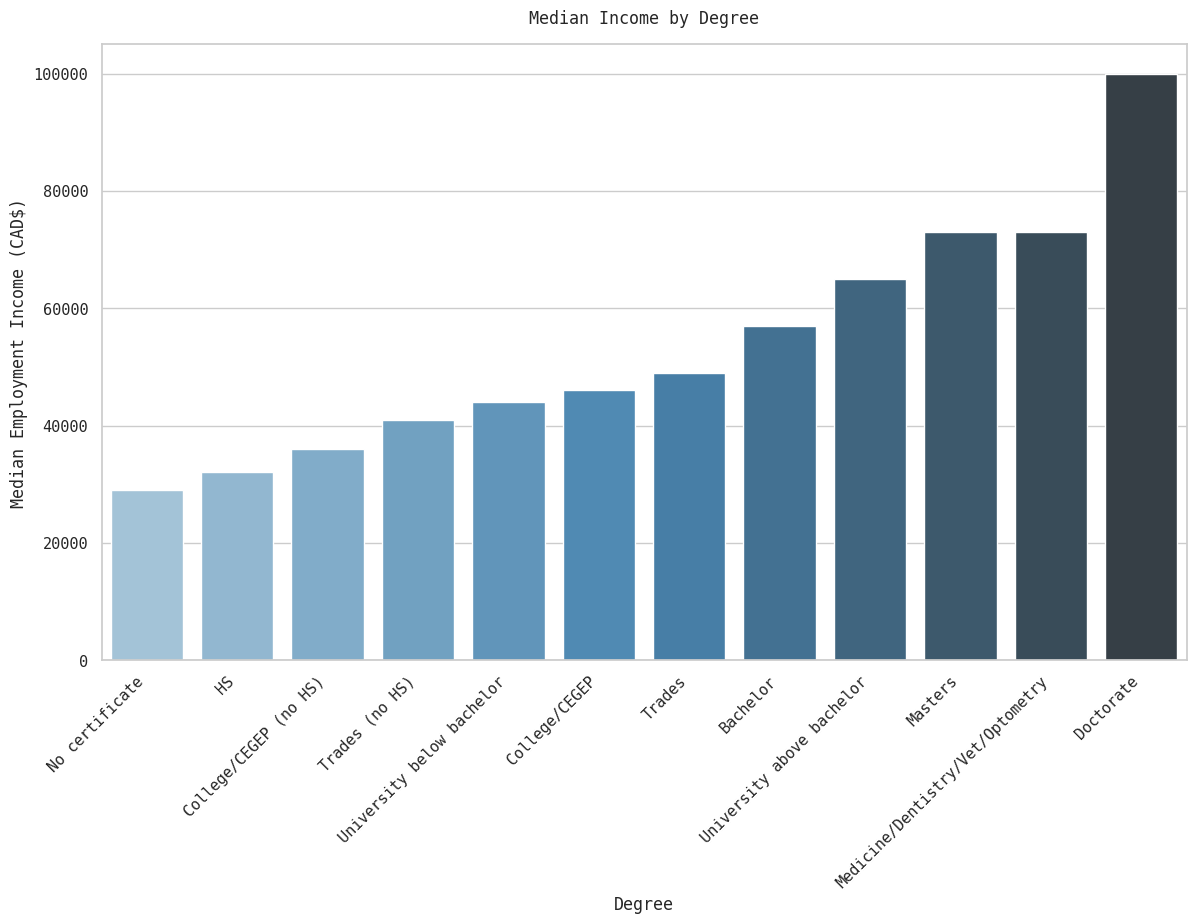

In [23]:
sns.set_theme(style="whitegrid", font="Monospace", font_scale=1, rc={'figure.figsize': (14, 8)})
median_deg = mapped_df.groupby('Degree')['EmpIn'].median().sort_values()
g = sns.barplot(median_deg, palette="Blues_d", legend=False)
g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
g.set_xlabel('Degree')
g.set_ylabel('Median Employment Income (CAD$)')
g.set_title('Median Income by Degree', y=1.02)
plt.show()

We see a pretty linear increase as levels of education increase, but not all degree jumps are equal. Getting a bachelor (vs HS) increases your earnings by roughly 80%, where a masters merely gives you ~$20k on top of that, but for a 2 year investment. It may be justified if you're getting a doctorate, at the cost of an additional 3 years of study but with nearly double the median earnings of a bachelor - it will not take long to earn the money back.  The difference in trades and a bachelor expressed like this is minor, worse when you consider the lower time expenditure and debt burden; however, we've already calculated the NPV to find that a bachelor still makes sense.

/tmp/ipykernel_47961/1071762036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(median_fos, palette='Blues_d')
/tmp/ipykernel_47961/1071762036.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')


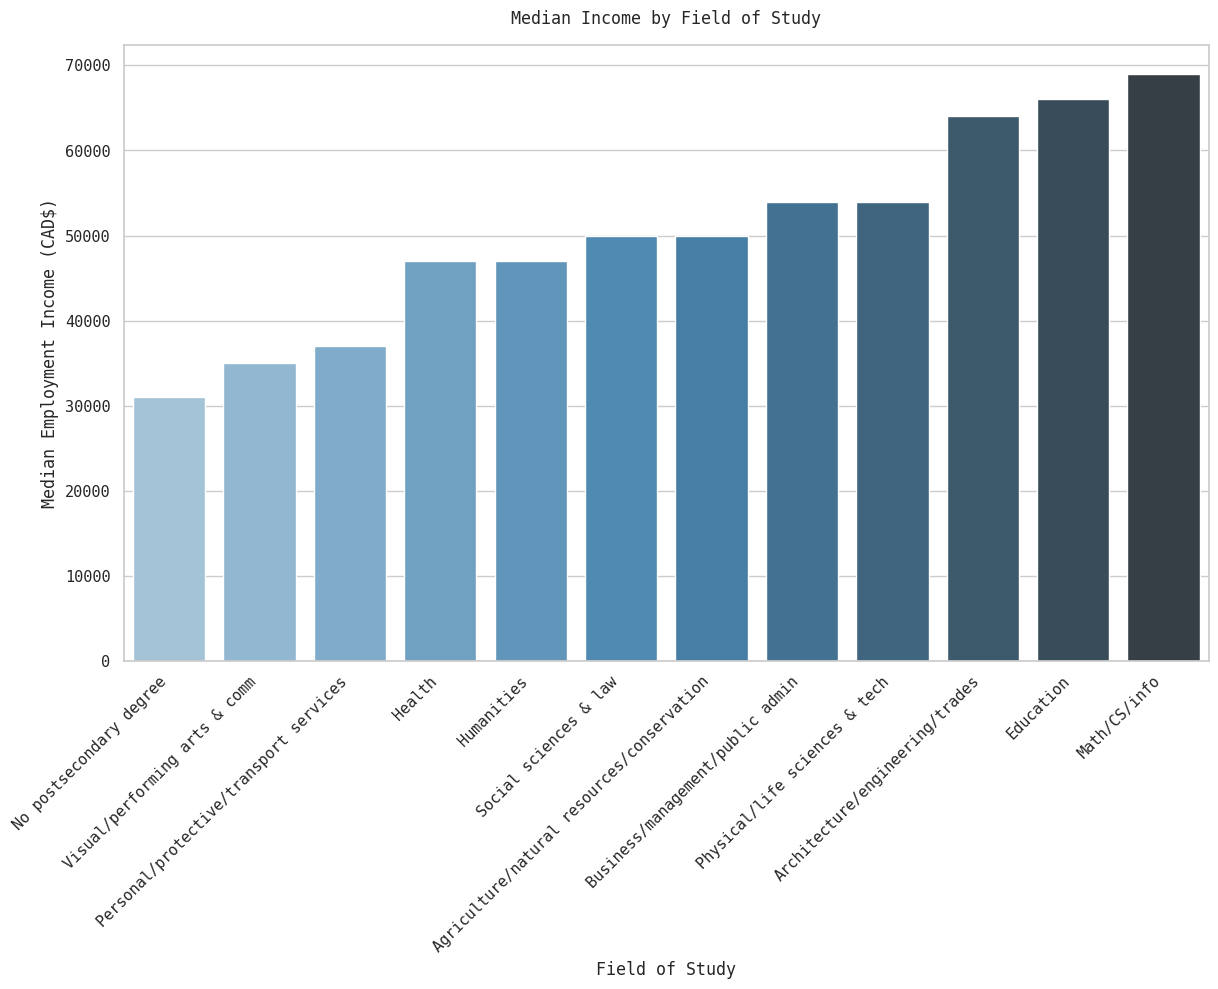

In [24]:
median_fos = mapped_df.groupby('FOS')['EmpIn'].median().sort_values()
g = sns.barplot(median_fos, palette='Blues_d')
g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
g.set_xlabel('Field of Study')
g.set_ylabel('Median Employment Income (CAD$)')
g.set_title('Median Income by Field of Study', y=1.02)
plt.show()

There is a wide variation in median earnings by field of study as well - STEM (and, curiously, 'education') pays the most and the arts and humanities pay the least. Education can be explained by the fact that teachers are paid handsomely in Ontario ['with salaries ranging from $65,000 to $110,000 per year'](https://www.remitly.com/blog/en-ca/jobs-and-careers/teacher-salary/). As a category, social sciences & law may make sense academically but does complicate our analysis: law degrees and sociology majors will likely get paid quite differently.

/tmp/ipykernel_47961/3386662314.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
/tmp/ipykernel_47961/3386662314.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


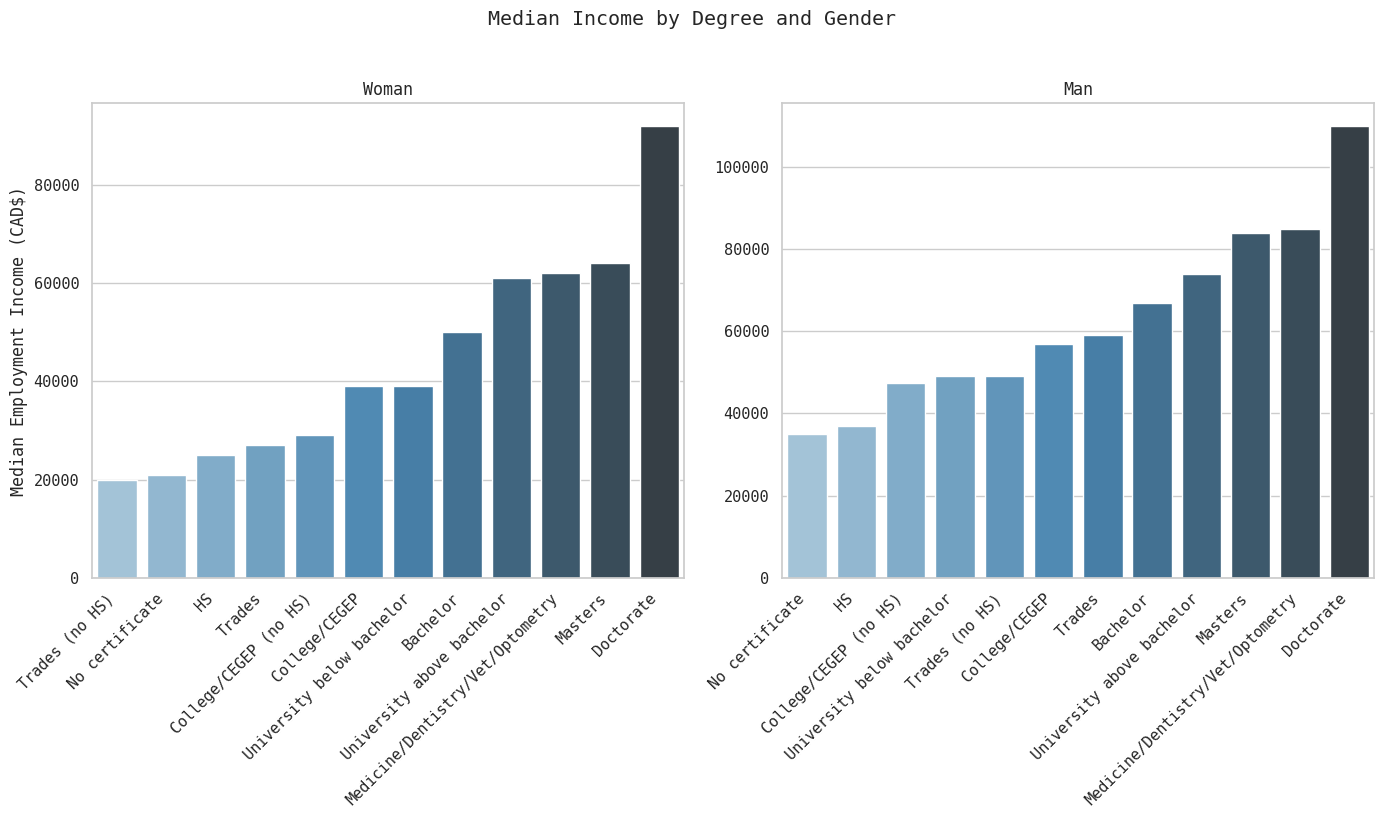

In [25]:
gen_median_deg = mapped_df.groupby(['gen', 'Degree'])['EmpIn'].median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=False)

genders = ['Woman', 'Man']

for ax, gender in zip(axes, genders):
    data = gen_median_deg[gender]
    sns.barplot(x=data.index, y=data.values, ax=ax, palette='Blues_d', hue=data.index)
    ax.set_title(gender)
    ax.set_xlabel('')
    ax.set_ylabel('Median Employment Income (CAD$)' if gender == 'Woman' else '')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

fig.suptitle('Median Income by Degree and Gender', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_47961/3188233868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(gap_deg['Gap'].sort_values(ascending=False), palette='Blues_d')
/tmp/ipykernel_47961/3188233868.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')


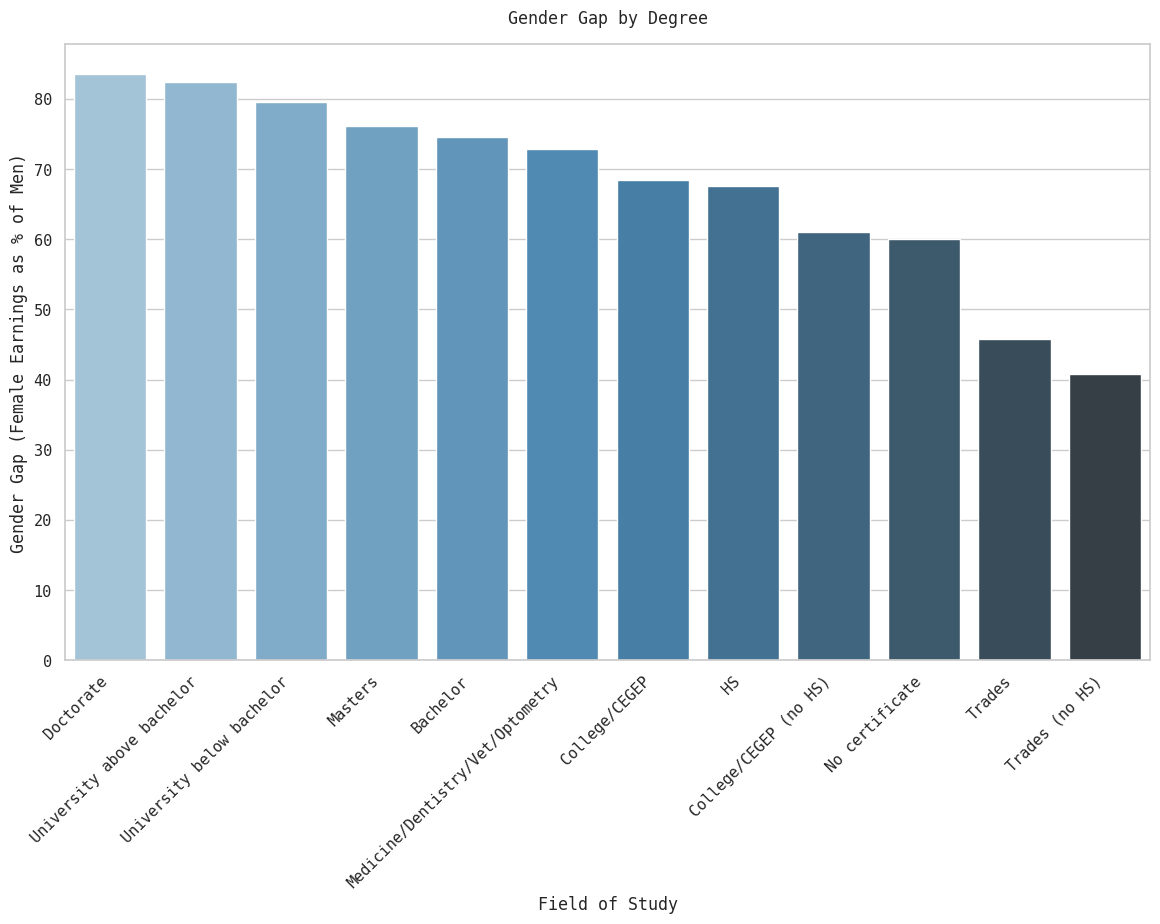

In [26]:
gap_deg = gen_median_deg.unstack(level=0)
gap_deg['Gap'] = ((gap_deg['Woman'] / gap_deg['Man']) * 100)
g = sns.barplot(gap_deg['Gap'].sort_values(ascending=False), palette='Blues_d')
g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
g.set_xlabel('Field of Study')
g.set_ylabel('Gender Gap (Female Earnings as % of Men)')
g.set_title('Gender Gap by Degree', y=1.02)
plt.show()

This data is unsurprising. The more educated women are, the more they surmount the gender pay gap - the situation, as common-sense would tell you, is worst in the trades. What's surprising is that women without any certification (in terms of gender gap relative to male counterparts, not absolute income) do better in this regard. Of course, 'No certificate' is an odd category, likely a small number of immigrants or refugees who don't have any Canadian certifications, and you shouldn't read too much into it. The reasons for the pay gap declining by degree are manifold, and beyond the scope of this post.

/tmp/ipykernel_47961/949474903.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
/tmp/ipykernel_47961/949474903.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


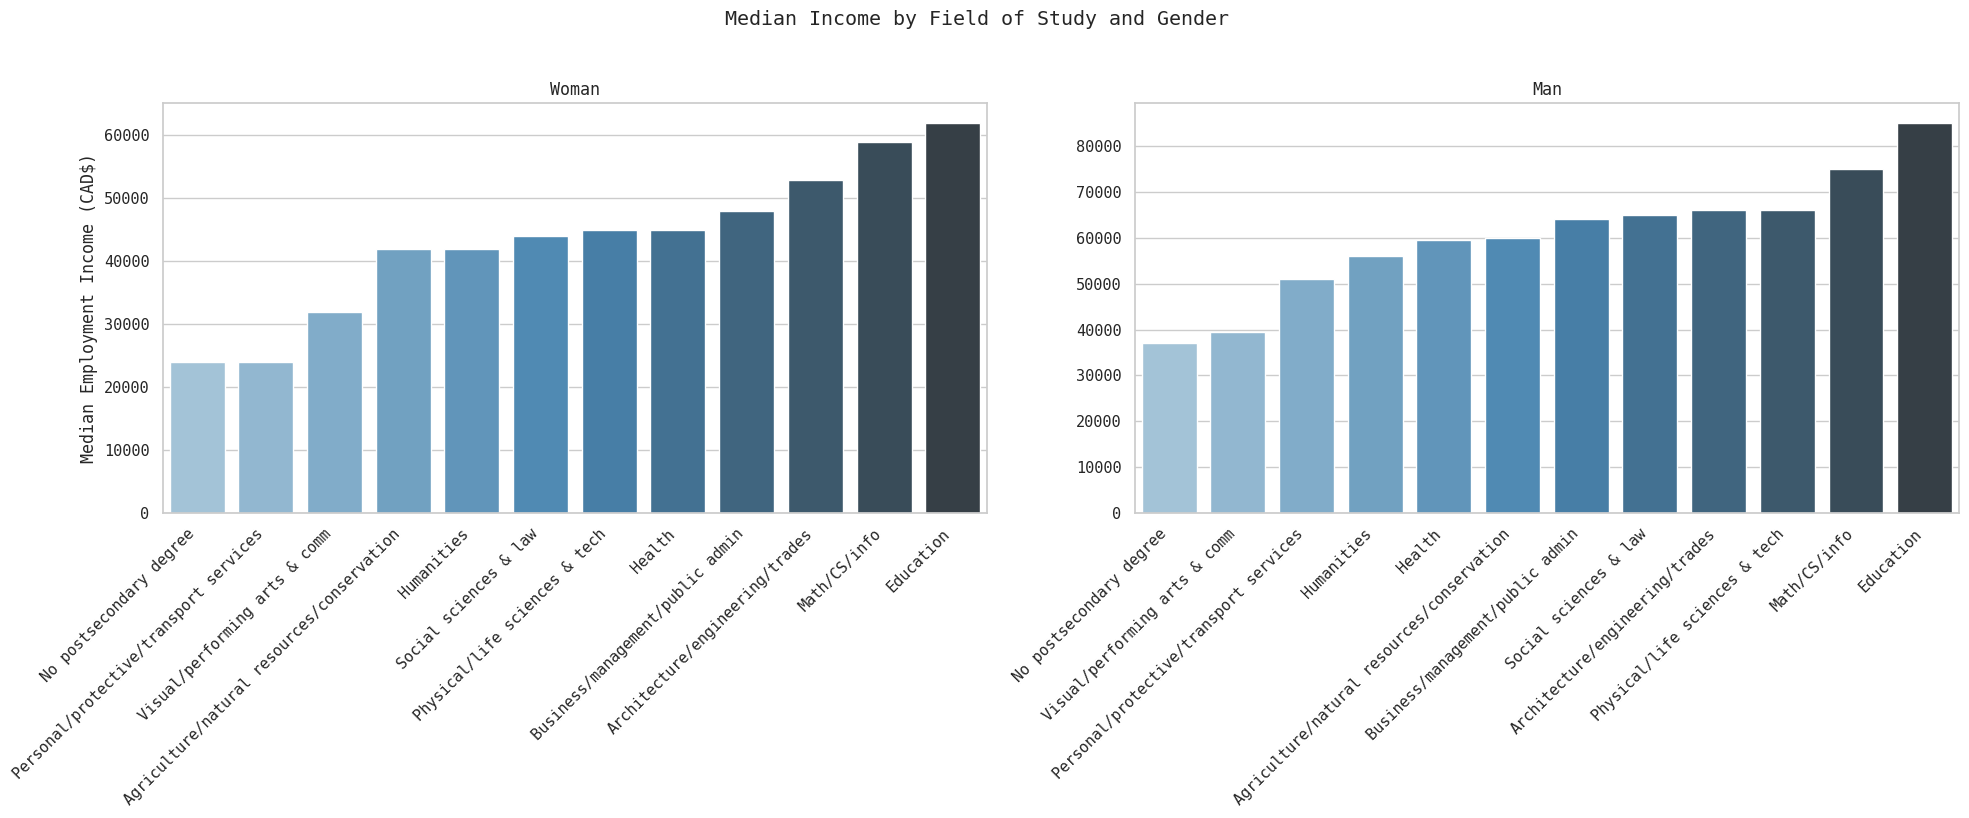

In [27]:
gen_median_fos = mapped_df.groupby(['gen', 'FOS'])['EmpIn'].median()
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=False)

genders = ['Woman', 'Man']

for ax, gender in zip(axes, genders):
    data = gen_median_fos[gender].sort_values()
    sns.barplot(x=data.index, y=data.values, ax=ax, palette='Blues_d', hue=data.index)
    ax.set_title(gender)
    ax.set_xlabel('')
    ax.set_ylabel('Median Employment Income (CAD$)' if gender == 'Woman' else '')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

fig.suptitle('Median Income by Field of Study and Gender', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_47961/989514706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(gap['Gap'].sort_values(ascending=False), palette='Blues_d')
/tmp/ipykernel_47961/989514706.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')


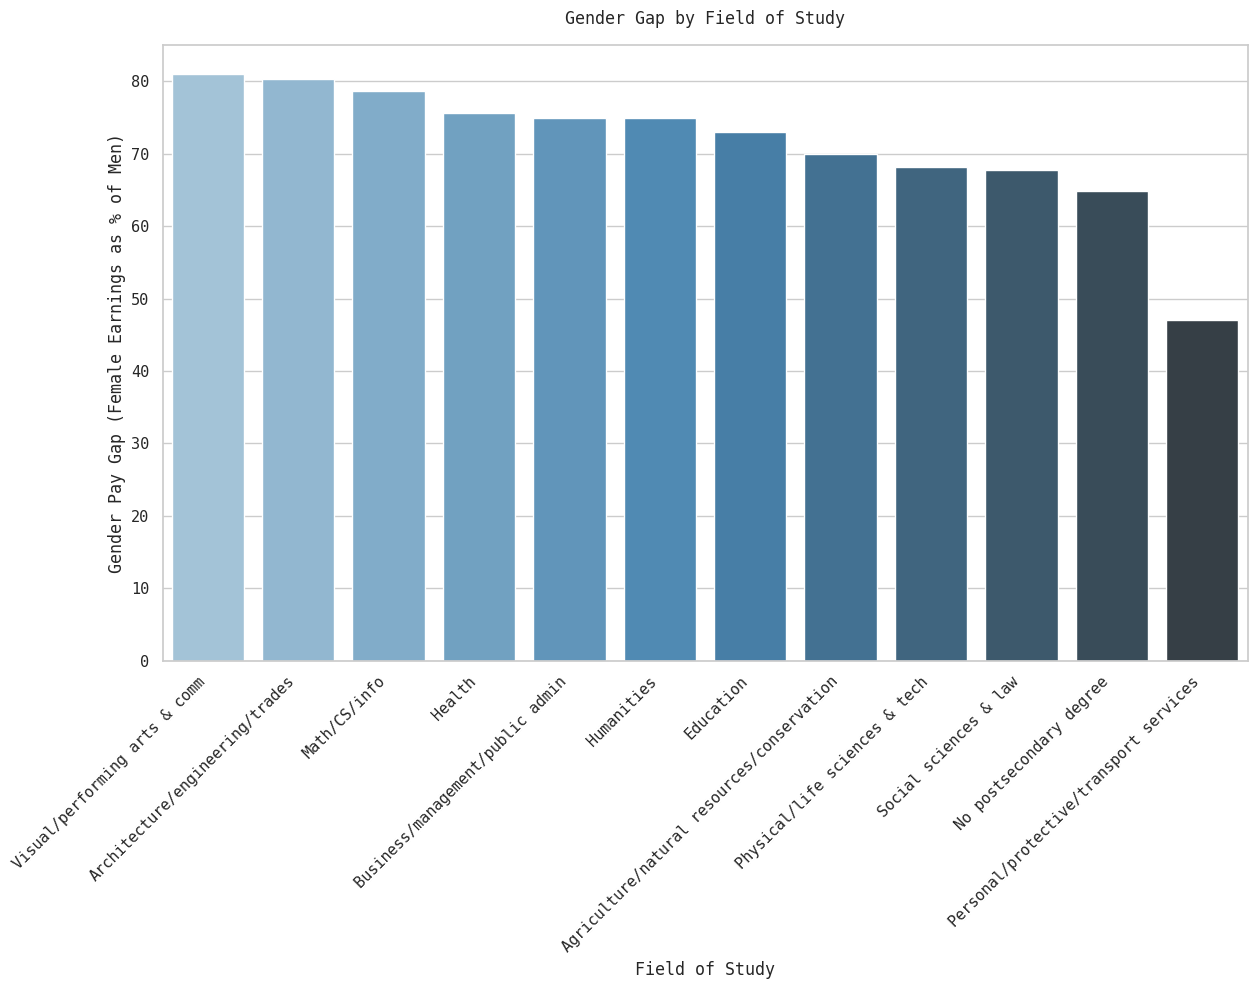

In [28]:
gap = gen_median_fos.unstack(level=0)
gap['Gap'] = ((gap['Woman'] / gap['Man']) * 100)
g = sns.barplot(gap['Gap'].sort_values(ascending=False), palette='Blues_d')
g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment='right')
g.set_xlabel('Field of Study')
g.set_ylabel('Gender Pay Gap (Female Earnings as % of Men)')
g.set_title('Gender Gap by Field of Study', y=1.02)
plt.show()

Women in the performing arts and 'comm', and STEM suffer the lowest gender pay gaps. The worst pay gap is in 'personal/protective/transport services', the non-degree category, and social sciences & law. The latter may be explained primarily through the law subcategory. Lawyer jobs are extremely demanding ('greedy') and women tend to disprefer such jobs; female representation in that category, therefore, will likely be in the lower-paying degrees in the social sciences, therefore skewing the category's gap. 

## Field of Study Comparisons

Back to the plot. Rationally speaking, there's really no argument against even maximal changes to the loan and grant ratio for OSAP. Of course, (future) students are *relatively* worse off and that is a negative, regardless of whether you think it's a sufficient criticism (for that, you'd need to analyse a whole lot more than just ROI, including Ontario's fiscal space). But is that really all there is to it? Let's break down the analysis into more granular terms to get a clearer picture before our final conclusion. We will calculate NPV by the following categories:

1. Field of Study
2. Gender

We could also do so by degree, but degree finances get more and more complicated as you go up the chain - doctorates being worst in this regard. Such an analysis would require a separate notebook.

I will do two separate analyses: one will compare a bachelors to a hs diploma, the other will compare a bachelors to a trades degree, by field of study.

Both analyses will use a pessimistic scenario for osap ratios: 100% loans.

In [29]:
# Filters for post-secondary degrees
ps_df = mapped_df.copy()

# This model doesn't include edu_years to prevent multicollinearity
model_fos = sm.OLS.from_formula('log_wage ~ edu_years + C(FOS)*exp_years + C(FOS)*I(exp_years**2) + C(Gender)', data=ps_df)
results_fos = model_fos.fit()

results_fos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_wage   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                     626.4
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:07:43   Log-Likelihood:            -3.3861e+05
No. Observations:              182864   AIC:                         6.773e+05
Df Residuals:                  182826   BIC:                         6.777e+05
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
======================================================================================================================================
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                              7.6506      0.105     72.889      0.000       7.445       7.856
C(FOS)[T.Architecture/engineering/trades]                              0.0265      0.101      0.261      0.794      -0.172       0.225
C(FOS)[T.Business/management/public admin]                             0.0067      0.100      0.067      0.947      -0.190       0.203
C(FOS)[T.Education]                                                   -0.2288      0.122     -1.880      0.060      -0.467       0.010
C(FOS)[T.Health]                                                       0.0384      0.102      0.376      0.707      -0.162       0.239
C(FOS)[T.Humanities]                                                  -0.3519      0.112     -3.130      0.002      -0.572      -0.132
C(FOS)[T.Math/CS/info]                                                -0.0971      0.110     -0.885      0.376      -0.312       0.118
C(FOS)[T.No postsecondary degree]                                     -0.6518      0.099     -6.571      0.000      -0.846      -0.457
C(FOS)[T.Personal/protective/transport services]                      -0.1255      0.112     -1.118      0.263      -0.345       0.094
C(FOS)[T.Physical/life sciences & tech]                               -0.5344      0.107     -4.984      0.000      -0.745      -0.324
C(FOS)[T.Social sciences & law]                                       -0.1646      0.101     -1.623      0.105      -0.363       0.034
C(FOS)[T.Visual/performing arts & comm]                               -0.5159      0.114     -4.528      0.000      -0.739      -0.293
C(Gender)[T.2]                                                         0.3653      0.008     46.602      0.000       0.350       0.381
edu_years                                                              0.1216      0.003     45.412      0.000       0.116       0.127
exp_years                                                              0.1069      0.011     10.079      0.000       0.086       0.128
C(FOS)[T.Architecture/engineering/trades]:exp_years                    0.0014      0.011      0.126      0.900      -0.020       0.023
C(FOS)[T.Business/management/public admin]:exp_years                  -0.0074      0.011     -0.672      0.501      -0.029       0.014
C(FOS)[T.Education]:exp_years                                          0.0234      0.013      1.795      0.073      -0.002       0.049
C(FOS)[T.Health]:exp_years                                            -0.0220      0.011     -1.955      0.051      -0.044    5.06e-05
C(FOS)[T.Humanities]:exp_years                                        -0.0027      0.012     -0.216      0.829   

In [30]:
hs_npvs = {}
for fos in ps_df['FOS'].dropna().unique():
    if fos == 'No postsecondary degree':
        continue
    npvs = osap_npv(ratio=0, main_model=results_fos, sec_model=results, 
                    bFos=True, fos=fos)
    hs_npvs[fos] = npvs

hs_npvs_df = pd.DataFrame.from_dict(hs_npvs, orient='index', columns=['Male', 'Female'])
hs_npvs_df

,Male,Female
Architecture/engineering/trades,511710.016950,357405.052259
Social sciences & law,333757.556643,233903.671114
Business/management/public admin,427342.998907,298853.216373
Math/CS/info,458971.503149,320803.820208
Health,349597.080201,244896.511745
Education,378718.398483,265107.095080
Humanities,109472.619446,78246.932983
Personal/protective/transport services,203982.747130,143838.222258
Physical/life sciences & tech,278627.998659,195643.022505
Visual/performing arts & comm,35355.603031,26808.734951


/tmp/ipykernel_47961/1295039004.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
/tmp/ipykernel_47961/1295039004.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


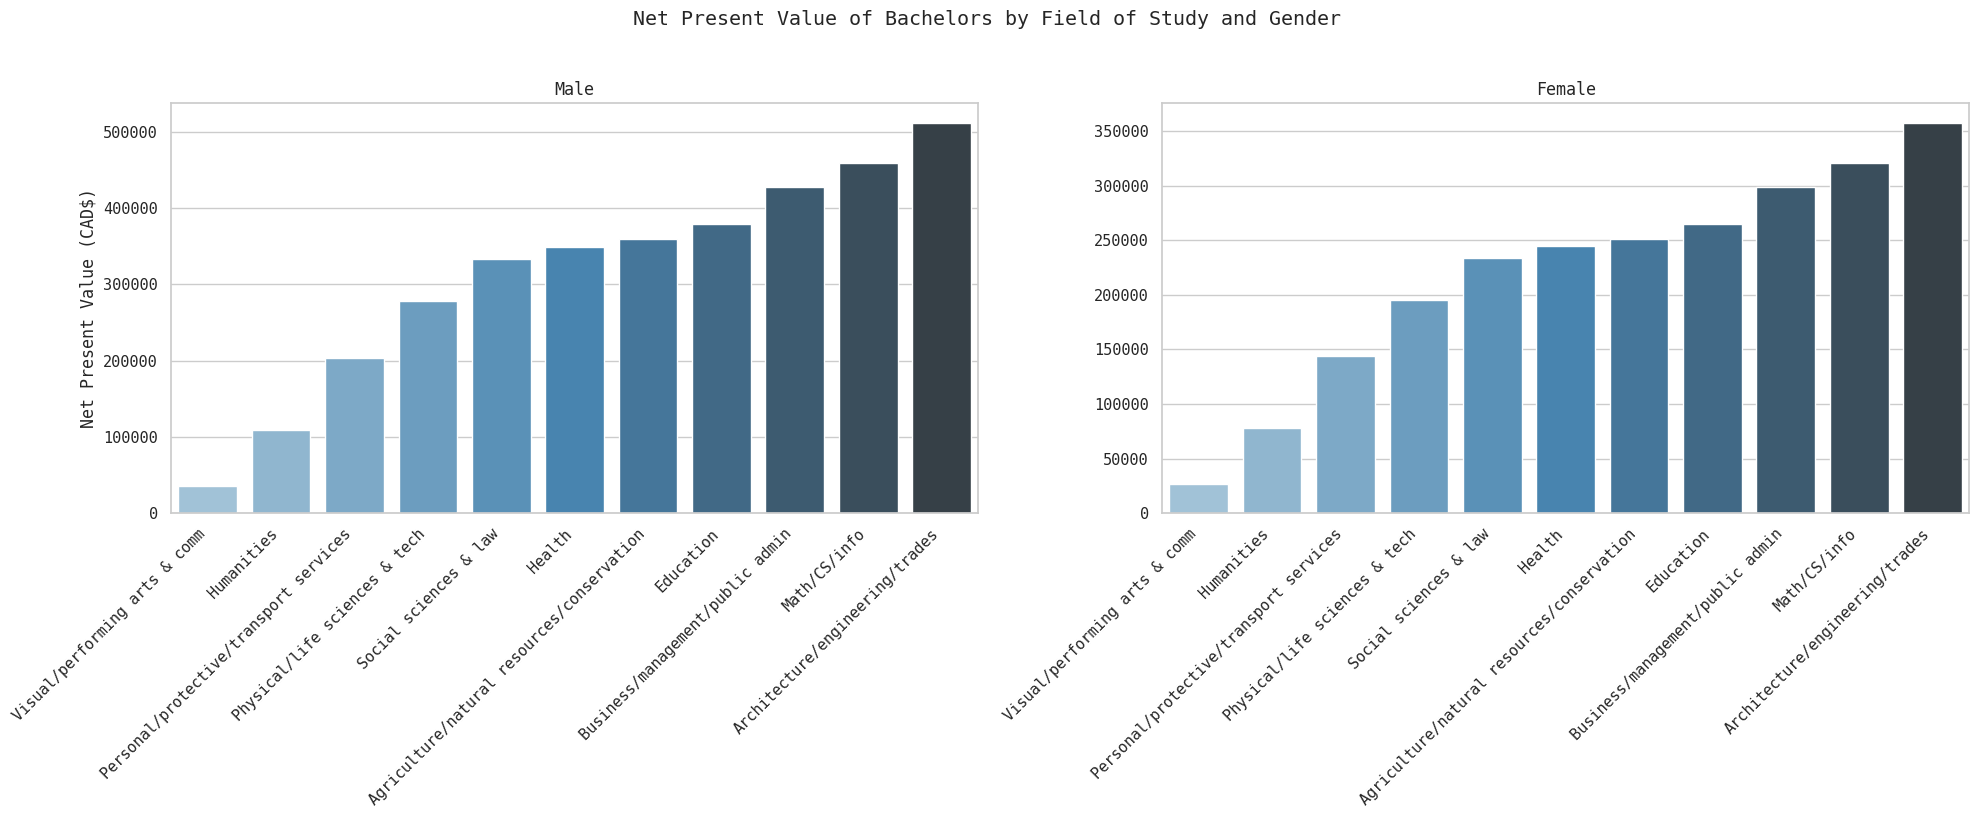

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=False)

genders = ['Male', 'Female']

for ax, gender in zip(axes, genders):
    data = hs_npvs_df[gender].sort_values()
    sns.barplot(x=data.index, y=data.values, ax=ax, palette='Blues_d', hue=data.index)
    ax.set_title(gender)
    ax.set_xlabel('')
    ax.set_ylabel('Net Present Value (CAD$)' if gender == 'Male' else '')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

fig.suptitle('Net Present Value of Bachelors by Field of Study and Gender', y=1.02)
plt.tight_layout()
plt.show()

We see an extremely vide variation in NPV as well. The counterfactual here is a high school degree. Overall, all fields of study are still a net positive, but the arts are close to having a negative ROI. 

In [32]:
trade_npvs = {}
for fos in ps_df['FOS'].dropna().unique():
    if fos == 'No postsecondary degree':
        continue
    npvs = osap_npv(ratio=0, main_model=results_fos, sec_model=results, bFos=True, fos=fos, sec_edu=13)
    trade_npvs[fos] = npvs

trade_npvs_df = pd.DataFrame.from_dict(trade_npvs, orient='index', columns=['Male', 'Female'])
trade_npvs_df

,Male,Female
Architecture/engineering/trades,429552.143647,301687.835761
Social sciences & law,251599.683340,178186.454616
Business/management/public admin,345185.125603,243135.999875
Math/CS/info,376813.629846,265086.603709
Health,267439.206897,189179.295247
Education,296560.525180,209389.878582
Humanities,27314.746143,22529.716485
Personal/protective/transport services,121824.873827,88121.005760
Physical/life sciences & tech,196470.125356,139925.806007
Visual/performing arts & comm,-46802.270272,-28908.481547


/tmp/ipykernel_47961/961882529.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
/tmp/ipykernel_47961/961882529.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


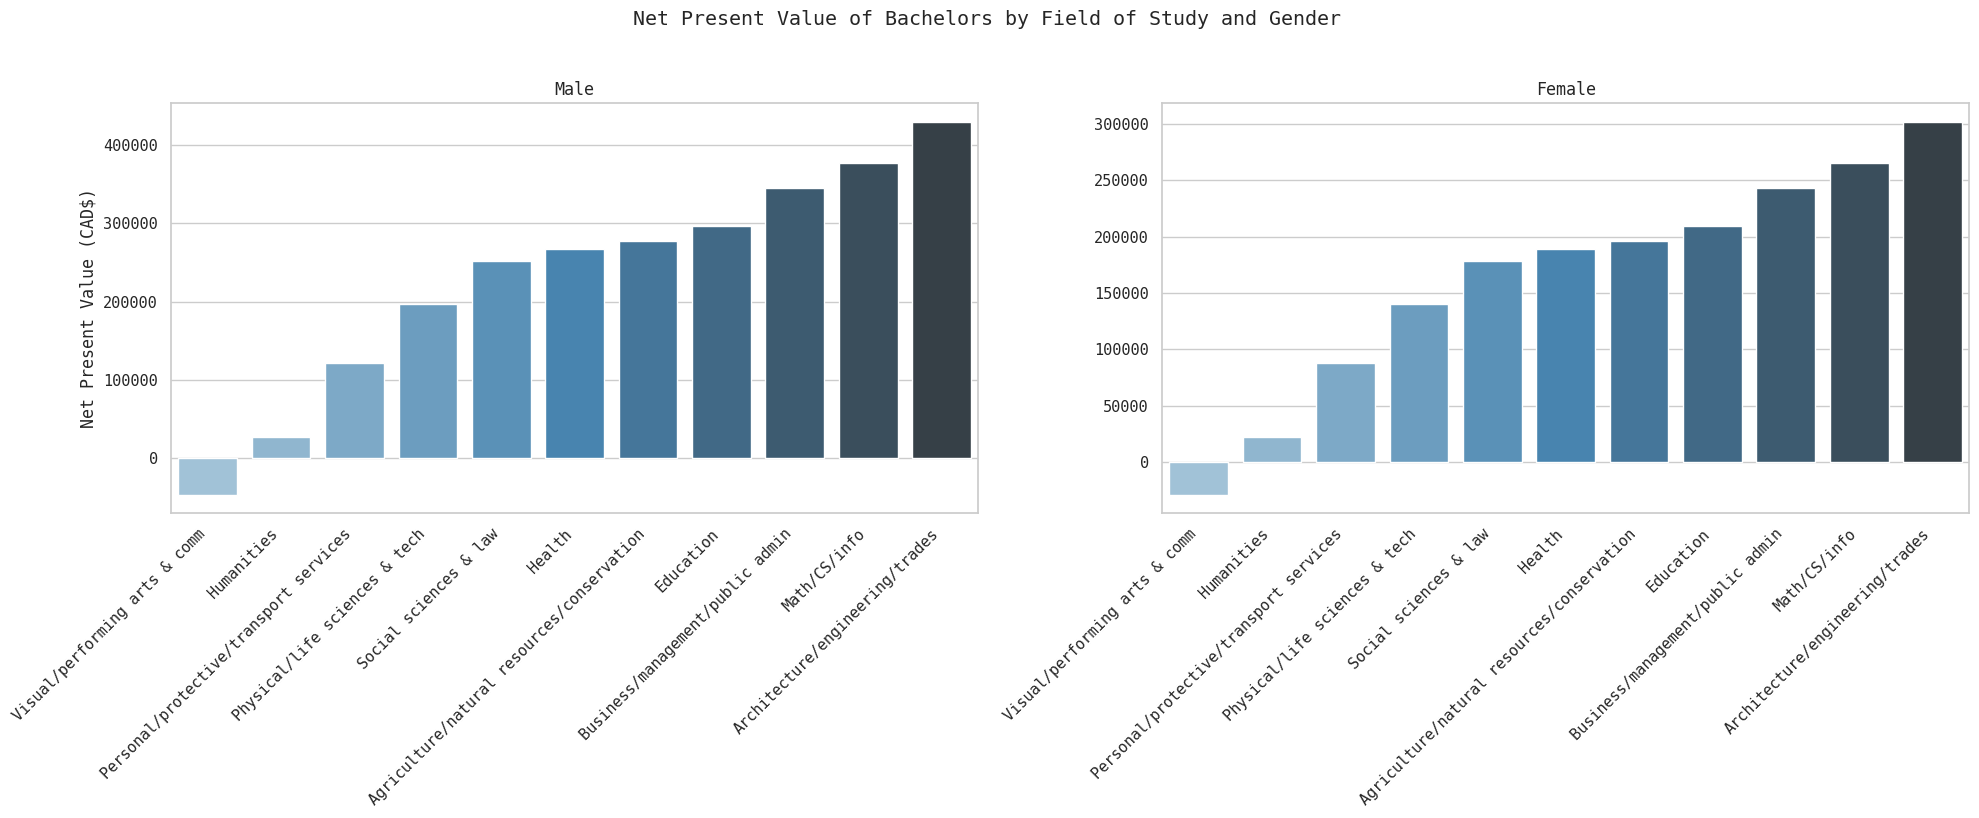

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=False)

genders = ['Male', 'Female']

for ax, gender in zip(axes, genders):
    data = trade_npvs_df[gender].sort_values()
    sns.barplot(x=data.index, y=data.values, ax=ax, palette='Blues_d', hue=data.index)
    ax.set_title(gender)
    ax.set_xlabel('')
    ax.set_ylabel('Net Present Value (CAD$)' if gender == 'Male' else '')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

fig.suptitle('Net Present Value of Bachelors by Field of Study and Gender', y=1.02)
plt.tight_layout()
plt.show()

We finally get our first instance of education with a negative ROI - compared to becoming a skilled tradesman, getting an arts degree is a bad investment. Humanities really toes it close to zero, but is positive with a NPV of $~20k for both genders. Beyond that however, most fields still offer a substantial (>$100k) positive ROI for both genders.

## Conclusion

In sum, education offers a positive ROI regardless of gender, grant/loan ratios, and field of study (with the sole exception of visual/performing arts vs trades) relative to a high school diploma and trades. There is wide variance between fields of study and degree type, and a substantial gender gap that also varies by FoS/Degree. 

On average, men earn ~47% more than women controlling for education and experience. This is a 'naive' gap - the entire difference is not made up solely of discrimination, since our model does not account for many variables. Generally, the gender gap decreases as women climb the education ladder and it is lowest in the Arts and STEM fields (this is just the gap, and does not account for absolute income). There is a substantial pay gap in the trades, as well. Put together, this tells us that education is likely a more important investment for women relative to men.

OSAP's recent changes make no difference to the NPV of education. Through a sensitivity analysis comparing grant/loan ratios, I found that even in the worst case scenario (100% loans), the NPV of education (compared to a counterfactual trades degree) is $270k for men and $180k for women. The OSAP ratio change actually makes very little difference at all - this is largely because 70% of federal loans are interest-free. The number does vary by field of study - visual/performing arts degrees are negative (<$10k), and humanities degrees offer an insubstantial ROI (~$20k for both genders), but most other fields offer >$100k returns. This tells us that recent or anticipated OSAP changes should not affect your college plans, except where your liquidity is questionable (i.e. OSAP does not cover 100% of college costs, and you can not make up the difference).


### Limitations

Many of these limitations are for simplicity's sake - to prevent this notebook from becoming too large. It bears listing them, however. There are also specific limitations listed in their relevant sections.

- My models factor unemployment in through its effect (drag) on income, not as a separate variable. A more complex model would handle this factor separately and properly. This could be done by modelling employment probability separately and combining *that* with income predictions.
- Experience calculation is also affected similarly - few people would have 45 years of experience at the end of their working lifetime, because that assumes continuous employment (i.e. no unemployment). 
- My models do not control for that many variables - hence the low R^2 of ~0.1. These include specific factors relevant to income, like part-time/full-time work or hours worked per week, and general factors like race or immigration status. 
- My models do not account for the weights given by PUMF. That means my model is not ideal for population-level results - this is fine for measuring relationships, but knocks my precision.
- Immigrants might deserve a separate notebook, esp. for those with foreign education.
- I use an interest rate of 6% throughout my calculations. An extension of this notebook would be to perform a sensitivity analysis.
- There are some simplifications when calculating OSAP loan annuities. There is a 6-month grace period, and the actual time horizon is 9.5 years (where I use 10). Since my cash flow models annual income, it is difficult to accomodate this - hence the simplification. There are also tax considerations vis-a-vis both income and student loan tax credits that I have ignored.
